# SDE to Score-Based Generation (1)


This note has two connected parts:

- **Part I:** SDE basics (Brownian motion, GBM, OU, distribution evolution)
- **Part II:** score-based generation (score learning, denoising, sampling)

**Relation in one sentence:** Part I describes the forward noising dynamics; Part II learns the reverse dynamics to generate data.

---

## Part I — SDE Foundations

### 1.1 Stochastic process

We consider the discrete-time stochastic process

$$
x_{t+\Delta t} = x_t + \sqrt{\Delta t}\, z_t,
\qquad z_t \sim \mathcal N(0,1).
$$

Equivalently,
$$
\Delta x \sim \mathcal N(0,\Delta t).
$$

As $\Delta t \to 0$, this converges to the stochastic differential equation

$$
dx_t = dW_t,
$$

where $W_t$ is standard Brownian motion.

Properties:
- $$\mathbb{E}[x_t] = x_0$$
- $$\mathrm{Var}(x_t) = t$$

The gray shaded region in the plots corresponds to the $$ \pm 2\sqrt{t} $$ band.


In [ ]:
from IPython.display import HTML

HTML("""
<style>
/* Page margins + centered content for notebook/voila rendering */
body {
  max-width: 1280px;
  margin: 0 auto !important;
  padding: 0 32px 24px 32px !important;
  box-sizing: border-box;
}

.jp-Notebook, .jp-NotebookPanel-notebook, .jp-Cell, .voila-app {
  max-width: 1280px !important;
  margin-left: auto !important;
  margin-right: auto !important;
}

@media (max-width: 900px) {
  body {
    padding: 0 16px 16px 16px !important;
  }
}
</style>
""")

In [22]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def simulate_path(T=3.0, dt=0.25, x0=0.0):
    """
    Simulate x_{t+dt} = x_t + sqrt(dt) * z,  z ~ N(0,1)
    """
    n = int(T / dt)
    t = np.linspace(0, n*dt, n+1)
    z = rng.standard_normal(n)
    dw = np.sqrt(dt) * z
    x = np.zeros(n+1)
    x[0] = x0
    x[1:] = x0 + np.cumsum(dw)
    return t, x

def two_sigma_band(t, x0=0.0):
    s = 2 * np.sqrt(t)
    return x0 - s, x0 + s


In [ ]:
from ipywidgets import interact, FloatSlider


def plot_path_by_dt(delta_t=0.25):
    T = 3.0
    x0 = 0.0

    t, x = simulate_path(T=T, dt=delta_t, x0=x0)
    lo, hi = two_sigma_band(t, x0)

    fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
    ax.fill_between(t, lo, hi, color="gray", alpha=0.2)

    if delta_t >= 0.25:
        ax.step(t, x, where="post")
        ax.plot(t, x, "o", markersize=4)
    else:
        ax.plot(t, x)

    y_lim = max(4.0, 2.0 * np.sqrt(T) + 1.0)
    ax.set_title(f"Brownian path  Δt = {delta_t:.3f}")
    ax.set_xlim(0, T)
    ax.set_ylim(-y_lim, y_lim)
    ax.set_xlabel("Time, t")
    ax.set_ylabel(r"$x_t$")

    plt.tight_layout()
    plt.show()


interact(
    plot_path_by_dt,
    delta_t=FloatSlider(value=0.25, min=0.005, max=1.0, step=0.005, description="Δt")
);

interactive(children=(FloatSlider(value=0.25, description='Δt', max=1.0, min=0.005, step=0.005), Output()), _d…

### Mean and variance check

For Brownian motion:
$$
\mathbb{E}[x_T] = 0, \qquad \mathrm{Var}(x_T) = T.
$$

We verify this empirically by simulating many trajectories.


In [24]:
def simulate_many(T=3.0, dt=0.01, n_paths=20000):
    n = int(T / dt)
    z = rng.standard_normal((n_paths, n))
    dx = np.sqrt(dt) * z
    xT = dx.sum(axis=1)
    return xT

xT = simulate_many(T=3.0, dt=0.01)

print("Empirical mean:", np.mean(xT))
print("Empirical variance:", np.var(xT))
print("Theoretical variance:", 3.0)


Empirical mean: -0.0027468105259959904
Empirical variance: 2.992037828379828
Theoretical variance: 3.0


### 1.2 Example: Geometric Brownian Motion (GBM)

GBM is the SDE

$$
dx_t = \mu x_t\,dt + \sigma x_t\, dW_t,
$$

where $\mu$ is the drift and $\sigma$ is the volatility.

A closed-form solution is

$$
x_t = x_0 \exp\Big( (\mu-\tfrac12\sigma^2)t + \sigma W_t \Big).
$$

So $\log x_t$ is normal, i.e. $x_t$ is log-normal.

#### Mean and 95% interval

Using the closed form, we have

$$
\mathbb{E}[x_t] = x_0 e^{\mu t}.
$$

Also,
$$
\log x_t \sim \mathcal N\Big(\log x_0 + (\mu-\tfrac12\sigma^2)t,\ \sigma^2 t\Big).
$$

Therefore, a pointwise 95% interval can be taken as

$$
x_t^{\text{low}} = x_0 \exp\Big( (\mu-\tfrac12\sigma^2)t - 1.96\,\sigma\sqrt{t}\Big),
\quad
x_t^{\text{high}} = x_0 \exp\Big( (\mu-\tfrac12\sigma^2)t + 1.96\,\sigma\sqrt{t}\Big).
$$

We will plot:
- 3 sample paths (colored)
- mean (black dashed)
- 95% band (gray)


In [25]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def simulate_gbm_paths_em(mu, sigma, x0, T=2.0, dt=0.005, n_paths=3, rng=None):
    """
    GBM:
      x_{k+1} = x_k + mu x_k dt + sigma x_k dW_k
    Returns:
      t: (n+1,)
      X: (n_paths, n+1)
    """
    if rng is None:
        rng = np.random.default_rng()

    n = int(np.round(T / dt))
    t = np.linspace(0.0, n * dt, n + 1)

    X = np.zeros((n_paths, n + 1))
    X[:, 0] = x0

    z = rng.standard_normal((n_paths, n))
    dW = np.sqrt(dt) * z

    for k in range(n):
        X[:, k+1] = X[:, k] + mu * X[:, k] * dt + sigma * X[:, k] * dW[:, k]

    return t, X

def gbm_mean(mu, x0, t):
    return x0 * np.exp(mu * t)

def gbm_95_band(mu, sigma, x0, t):
    m = (mu - 0.5 * sigma**2) * t
    s = sigma * np.sqrt(t)
    lo = x0 * np.exp(m - 1.96 * s)
    hi = x0 * np.exp(m + 1.96 * s)
    return lo, hi


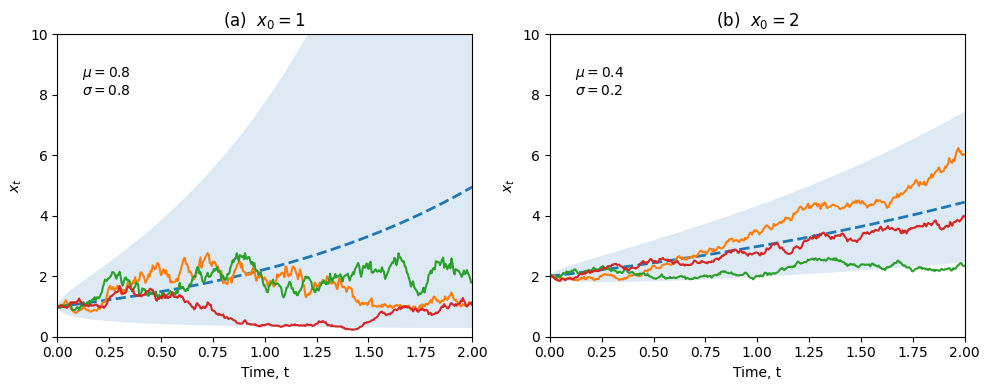

In [26]:
def plot_gbm_panel_em(ax, mu, sigma, x0, T=2.0, dt=0.005, n_paths=3, rng=None):
    t, X = simulate_gbm_paths_em(mu, sigma, x0, T=T, dt=dt, n_paths=n_paths, rng=rng)

    lo, hi = gbm_95_band(mu, sigma, x0, t)
    m = gbm_mean(mu, x0, t)

    ax.fill_between(t, lo, hi, alpha=0.15)          # 95% band (gray)
    ax.plot(t, m, linestyle="--", linewidth=2)      # mean (black dashed, default color)
    for i in range(n_paths):
        ax.plot(t, X[i], linewidth=1.5)             # sample paths

    ax.set_xlim(0, T)
    ax.set_ylim(0, 10)
    ax.set_xlabel("Time, t")
    ax.set_ylabel(r"$x_t$")
    ax.text(0.06, 0.90, rf"$\mu={mu}$"+"\n"+rf"$\sigma={sigma}$",
            transform=ax.transAxes, va="top")

# Parameters exactly like the screenshot
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# (a) mu=0.8, sigma=0.8, x0=1
plot_gbm_panel_em(axes[0], mu=0.8, sigma=0.8, x0=1.0, T=2.0, dt=0.005, n_paths=3, rng=rng)
axes[0].set_title("(a)  $x_0=1$")

# (b) mu=0.4, sigma=0.2, x0=2
plot_gbm_panel_em(axes[1], mu=0.4, sigma=0.2, x0=2.0, T=2.0, dt=0.005, n_paths=3, rng=rng)
axes[1].set_title("(b)  $x_0=2$")

plt.tight_layout()
plt.show()


In [27]:
def simulate_gbm_terminal_em(mu, sigma, x0, T=2.0, dt=0.005, n_paths=50000, rng=None):
    """
    Simulate only terminal value x_T using EM recursion (vectorized).
    """
    if rng is None:
        rng = np.random.default_rng()

    n = int(np.round(T / dt))
    x = np.full(n_paths, x0, dtype=float)

    z = rng.standard_normal((n_paths, n))
    dW = np.sqrt(dt) * z

    for k in range(n):
        x = x + mu * x * dt + sigma * x * dW[:, k]

    return x

def gbm_theory_mean(mu, x0, T):
    return x0 * np.exp(mu * T)

def gbm_theory_var(mu, sigma, x0, T):
    return (x0**2) * np.exp(2 * mu * T) * (np.exp(sigma**2 * T) - 1)

# Pick one setting to validate (use the "more noisy" case)
mu, sigma, x0, T = 0.8, 0.8, 1.0, 2.0
dt = 0.005
n_paths = 50000

xT = simulate_gbm_terminal_em(mu, sigma, x0, T=T, dt=dt, n_paths=n_paths, rng=rng)

emp_mean = float(np.mean(xT))
emp_var  = float(np.var(xT, ddof=0))

th_mean = float(gbm_theory_mean(mu, x0, T))
th_var  = float(gbm_theory_var(mu, sigma, x0, T))

print(f"EM Monte Carlo (n_paths={n_paths}, dt={dt}) at T={T}")
print("  empirical mean:", emp_mean)
print("  theory mean    :", th_mean)
print("  empirical var :", emp_var)
print("  theory var     :", th_var)


EM Monte Carlo (n_paths=50000, dt=0.005) at T=2.0
  empirical mean: 4.942884217342574
  theory mean    : 4.953032424395115
  empirical var : 62.37205728959269
  theory var     : 63.702142478542164


In [28]:
mu, sigma, x0, T = 0.8, 0.8, 1.0, 2.0
n_paths = 50000

for dt in [0.02, 0.01, 0.005, 0.002, 0.001]:
    xT = simulate_gbm_terminal_em(mu, sigma, x0, T=T, dt=dt, n_paths=n_paths, rng=rng)
    print(f"dt={dt:>6}  mean={np.mean(xT):.4f}  var={np.var(xT):.4f}")


dt=  0.02  mean=4.9477  var=60.7440
dt=  0.01  mean=4.8923  var=55.9510
dt= 0.005  mean=4.9796  var=64.3183
dt= 0.002  mean=4.9715  var=64.4960
dt= 0.001  mean=4.9783  var=70.5516


### 1.3 Example: Ornstein–Uhlenbeck (OU) process

The Ornstein–Uhlenbeck process is defined by the SDE

$$
dx_t = -\gamma x_t\,dt + \sigma\, dW_t,
$$

with $\gamma \ge 0$ and $\sigma > 0$.

This is a mean-reverting process:
- the drift term $-\gamma x_t$ pulls the state back toward zero,
- the noise term has constant scale.

#### Connection to diffusion models

A common parameterization in diffusion modeling is

$$
dx_t = -\tfrac12 \beta x_t\,dt + \sqrt{\beta}\, dW_t,
$$

where $\beta \in [0,1]$ controls how fast noise is injected.
As $t \to \infty$, the distribution of $x_t$ converges to standard normal.

#### Closed-form moments

The OU process has explicit solution

$$
x_t = x_0 e^{-\gamma t}
+ \frac{\sigma}{\sqrt{2\gamma}}\,
W_{\,1 - e^{-2\gamma t}} .
$$

Hence

$$
\mathbb{E}[x_t] = x_0 e^{-\gamma t},
\qquad
\mathrm{Var}(x_t) = \frac{\sigma^2}{2\gamma}\bigl(1 - e^{-2\gamma t}\bigr).
$$

We will plot:
- three sample paths,
- the mean (black dashed),
- the 95% confidence region (gray).


In [29]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def simulate_ou_paths(gamma, sigma, x0, T=8.0, dt=0.01, n_paths=3, rng=None):
    """
    Euler–Maruyama simulation of OU process:
      dx = -gamma x dt + sigma dW
    """
    if rng is None:
        rng = np.random.default_rng()

    n = int(np.round(T / dt))
    t = np.linspace(0.0, n * dt, n + 1)

    x = np.zeros((n_paths, n + 1))
    x[:, 0] = x0

    dW = np.sqrt(dt) * rng.standard_normal((n_paths, n))

    for k in range(n):
        x[:, k+1] = x[:, k] - gamma * x[:, k] * dt + sigma * dW[:, k]

    return t, x


In [32]:
def ou_mean(gamma, x0, t):
    return x0 * np.exp(-gamma * t)

def ou_var(gamma, sigma, t):
    return (sigma**2 / (2 * gamma)) * (1 - np.exp(-2 * gamma * t))

def ou_95_band(gamma, sigma, x0, t):
    m = ou_mean(gamma, x0, t)
    std = np.sqrt(ou_var(gamma, sigma, t))
    lo = m - 1.96 * std
    hi = m + 1.96 * std
    return lo, hi, m



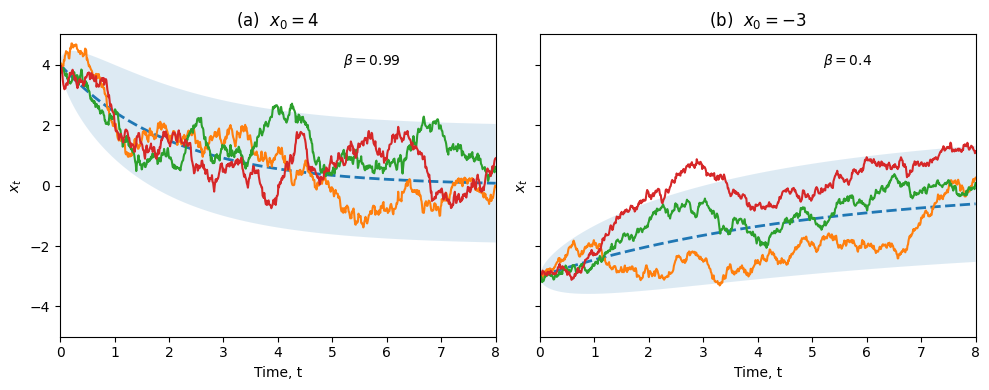

In [33]:
def plot_ou_panel(ax, beta, x0, T=8.0, dt=0.01, n_paths=3, rng=None):
    # diffusion parameterization
    gamma = 0.5 * beta
    sigma = np.sqrt(beta)

    t, X = simulate_ou_paths(gamma, sigma, x0, T=T, dt=dt,
                             n_paths=n_paths, rng=rng)

    m = ou_mean(gamma, x0, t)
    lo, hi, m = ou_95_band(gamma, sigma, x0, t)

    ax.fill_between(t, lo, hi, alpha=0.15)          # 95% region
    ax.plot(t, m, linestyle="--", linewidth=2)      # mean
    for i in range(n_paths):
        ax.plot(t, X[i], linewidth=1.5)             # samples

    ax.set_xlim(0, T)
    ax.set_ylim(-5, 5)
    ax.set_xlabel("Time, t")
    ax.set_ylabel(r"$x_t$")
    ax.text(0.65, 0.90, rf"$\beta={beta}$",
            transform=ax.transAxes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# (a) beta = 0.99, x0 = 4
plot_ou_panel(axes[0], beta=0.99, x0=4.0, rng=rng)
axes[0].set_title("(a)  $x_0 = 4$")

# (b) beta = 0.4, x0 = -3
plot_ou_panel(axes[1], beta=0.4, x0=-3.0, rng=rng)
axes[1].set_title("(b)  $x_0 = -3$")

plt.tight_layout()
plt.show()


### 1.4 Distribution evolution under an SDE

To move from single trajectories to distributional thinking, we simulate many trajectories using Euler–Maruyama (EM):

- Choose an initial distribution: $x_0 \sim P_0$
- Simulate the SDE forward in time
- Estimate $P(x\mid t)$ from trajectory histograms

We visualize:
- a background density heatmap for $P(x\mid t)$
- a few sample paths
- marginals at selected times

This bridges naturally to generative modeling: if we can understand and control how distributions evolve in time, we can design a reverse process to generate samples.


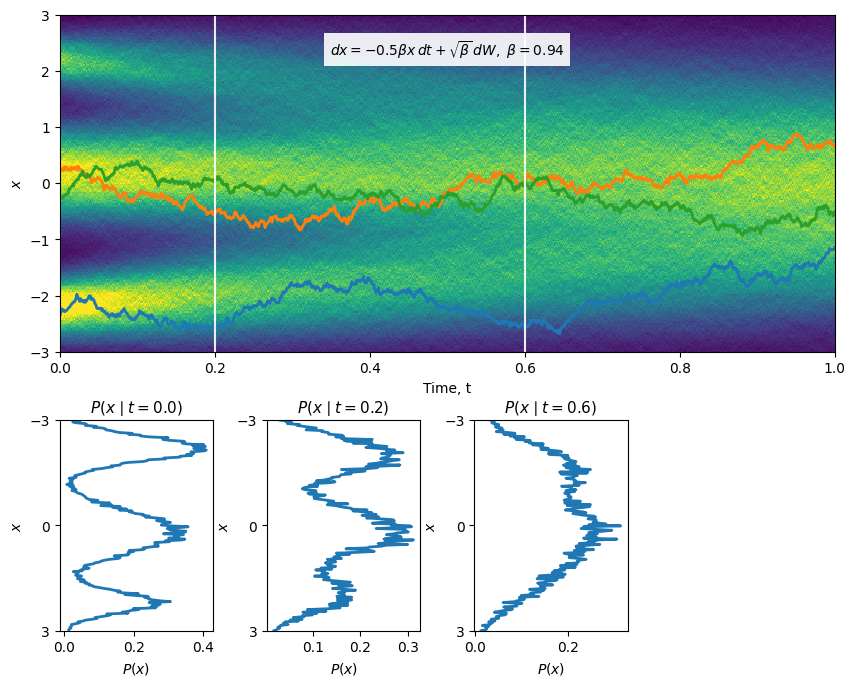

In [34]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# -----------------------------
# 1) You design the initial distribution here
# -----------------------------
def sample_x0(n, rng):
    """
    Return n samples from the initial distribution P0.
    You can replace this function with ANY sampler you want.

    Example: a 3-component Gaussian mixture (to look like the paper figure).
    """
    # mixture weights
    w = np.array([0.35, 0.45, 0.20])
    comp = rng.choice(len(w), size=n, p=w)

    means = np.array([-2.2,  0.2,  2.2])
    stds  = np.array([ 0.35, 0.55, 0.30])

    x0 = rng.normal(loc=means[comp], scale=stds[comp])
    return x0


# -----------------------------
# 2) EM simulation for diffusion SDE (OU form)
# dx = -0.5*beta*x dt + sqrt(beta) dW
# -----------------------------
def simulate_diffusion_em(x0, beta=0.94, T=1.0, dt=0.001, rng=None):
    """
    x0: shape (n_paths,) initial samples
    return:
      t: (n_steps+1,)
      X: (n_paths, n_steps+1)
    """
    if rng is None:
        rng = np.random.default_rng()

    n_paths = x0.shape[0]
    n_steps = int(np.round(T / dt))
    t = np.linspace(0.0, n_steps * dt, n_steps + 1)

    X = np.zeros((n_paths, n_steps + 1), dtype=float)
    X[:, 0] = x0

    z = rng.standard_normal((n_paths, n_steps))
    dW = np.sqrt(dt) * z

    drift_coeff = -0.5 * beta
    noise_scale = np.sqrt(beta)

    for k in range(n_steps):
        X[:, k+1] = X[:, k] + drift_coeff * X[:, k] * dt + noise_scale * dW[:, k]

    return t, X

def estimate_density_heatmap(X, x_grid, bins_as_grid=True):
    """
    Estimate density p(x|t) for each t via histogram over paths.
    X: (n_paths, n_steps+1)
    x_grid: (n_x,) grid for x-axis

    Return:
      P: (n_x, n_t) density estimate; columns correspond to times
    """
    n_paths, n_t = X.shape
    n_x = len(x_grid)

    # Use histogram bins aligned with x_grid
    # We'll build bin edges from x_grid midpoints.
    edges = np.zeros(n_x + 1)
    edges[1:-1] = 0.5 * (x_grid[:-1] + x_grid[1:])
    edges[0] = x_grid[0] - (edges[1] - x_grid[0])
    edges[-1] = x_grid[-1] + (x_grid[-1] - edges[-2])

    P = np.zeros((n_x, n_t), dtype=float)
    for j in range(n_t):
        hist, _ = np.histogram(X[:, j], bins=edges, density=True)
        P[:, j] = hist
    return P

def plot_sde_distribution_evolution(
    beta=0.94,
    T=1.0,
    dt=0.001,
    n_paths_for_density=40000,
    n_paths_for_lines=3,
    xlim=(-3, 3),
    t_slices=(0.0, 0.2, 0.6),
    rng=None
):
    if rng is None:
        rng = np.random.default_rng()

    # --- sample initial distribution
    x0_all = sample_x0(n_paths_for_density, rng=rng)

    # --- simulate many paths for density background
    t, X = simulate_diffusion_em(x0_all, beta=beta, T=T, dt=dt, rng=rng)

    # --- choose a few sample paths (draw from same initial pool)
    idx = rng.choice(n_paths_for_density, size=n_paths_for_lines, replace=False)
    X_lines = X[idx, :]

    # --- build x-grid and estimate density p(x|t)
    x_grid = np.linspace(xlim[0], xlim[1], 240)
    P = estimate_density_heatmap(X, x_grid)

    # For visualization, clip very large values a bit (helps contrast)
    P_vis = np.clip(P, 0, np.quantile(P, 0.995))

    # --- prepare layout: big panel + 3 small marginals
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(nrows=2, ncols=4, height_ratios=[3.2, 2.0], hspace=0.25, wspace=0.35)

    ax_main = fig.add_subplot(gs[0, :])
    ax_m1 = fig.add_subplot(gs[1, 0])
    ax_m2 = fig.add_subplot(gs[1, 1])
    ax_m3 = fig.add_subplot(gs[1, 2])
    ax_blank = fig.add_subplot(gs[1, 3])
    ax_blank.axis("off")

    # --- main heatmap (density over time)
    # extent: [t_min, t_max, y_min, y_max]
    extent = [t[0], t[-1], x_grid[-1], x_grid[0]]  # flip y so top is +x like paper
    ax_main.imshow(P_vis, aspect="auto", extent=extent, interpolation="nearest")

    # --- overlay sample paths
    for i in range(n_paths_for_lines):
        ax_main.plot(t, X_lines[i], linewidth=2)

    # --- vertical lines at slices
    for ts in t_slices:
        ax_main.axvline(ts, color="white", linewidth=1.5, alpha=0.9)

    ax_main.set_xlim(0, T)
    ax_main.set_ylim(xlim[0], xlim[1])
    ax_main.set_xlabel("Time, t")
    ax_main.set_ylabel(r"$x$")

    # equation label like paper
    eq_text = rf"$dx = -0.5\beta x\,dt + \sqrt{{\beta}}\,dW,\ \beta={beta}$"
    ax_main.text(0.50, 0.93, eq_text, transform=ax_main.transAxes,
                 ha="center", va="top", bbox=dict(facecolor="white", alpha=0.9, edgecolor="none"))

    # --- bottom marginals: plot P(x|t=ts) vs x (sideways like paper)
    def plot_marginal(ax, ts, title):
        j = int(np.round(ts / dt))
        j = max(0, min(j, len(t) - 1))
        p = P[:, j]
        ax.plot(p, x_grid, linewidth=2)
        ax.set_title(title, fontsize=11)
        ax.set_ylim(xlim[0], xlim[1])
        ax.invert_yaxis()  # match main orientation (top is +x)
        ax.set_yticks([xlim[0], 0, xlim[1]])
        ax.set_xlabel(r"$P(x)$")
        ax.set_ylabel(r"$x$")

    plot_marginal(ax_m1, t_slices[0], rf"$P(x\mid t={t_slices[0]})$")
    plot_marginal(ax_m2, t_slices[1], rf"$P(x\mid t={t_slices[1]})$")
    plot_marginal(ax_m3, t_slices[2], rf"$P(x\mid t={t_slices[2]})$")

    plt.show()


# --- run it
plot_sde_distribution_evolution(
    beta=0.94,
    T=1.0,
    dt=0.001,
    n_paths_for_density=30000,
    n_paths_for_lines=3,
    xlim=(-3, 3),
    t_slices=(0.0, 0.2, 0.6),
    rng=rng
)


## Part II — Application: Score-Based Generative Modeling

Part I focused on forward SDE dynamics and how distributions evolve. Part II asks the inverse question:

> Given noisy samples, how can we learn a vector field that points back to high-probability data regions and use it for generation?

### 2.1 Modeling a data distribution

We observe data

$$
x_1, \dots, x_N \sim p(x)
$$

Goal: model the unknown distribution $p(x)$.

A common parameterization:

$$
p_\theta(x) = \frac{e^{-f_\theta(x)}}{Z_\theta}
$$

where

$$
Z_\theta = \int e^{-f_\theta(x)} dx
$$

### 2.2 Traditional route: maximum likelihood

We train by

$$
\max_\theta\; \frac{1}{N}\sum_{i=1}^{N}\log p_\theta(x_i).
$$

For one sample:

$$
\nabla_\theta \log p_\theta(x)
= -\nabla_\theta f_\theta(x)
+ \mathbb E_{u\sim p_\theta}\!\left[\nabla_\theta f_\theta(u)\right].
$$

For the full dataset:

$$
\nabla_\theta\left(\frac{1}{N}\sum_{i=1}^{N}\log p_\theta(x_i)\right)
=\frac{1}{N}\sum_{i=1}^{N}
\left[
-\nabla_\theta f_\theta(x_i)
+ \mathbb E_{u\sim p_\theta}\left[\nabla_\theta f_\theta(u)\right]
\right].
$$

Core difficulty:
- estimating $\mathbb{E}_{u\sim p_\theta}[\nabla_\theta f_\theta(u)]$ requires sampling from $p_\theta$
- in high dimensions, MCMC mixing can be slow and unstable

---


### 2.3 Key idea: model the score instead of density values

Define the score

$$
s(x) = \nabla_x \log p(x).
$$

If two distributions have the same score field (up to regularity assumptions), they differ at most by a normalization constant.
So instead of estimating density values directly, we can learn their spatial gradients.

This avoids explicit handling of the partition function and leads to score matching objectives.

---


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from ipywidgets import interact, FloatSlider

def gaussian2d_pdf(X, Y, mx, my, sigma):
    norm = 1.0 / (2.0 * np.pi * sigma**2)
    z2 = ((X - mx)**2 + (Y - my)**2) / (sigma**2)
    return norm * np.exp(-0.5 * z2)

def gaussian2d_score(X, Y, mx, my, sigma):
    gx = -(X - mx) / (sigma**2)
    gy = -(Y - my) / (sigma**2)
    return gx, gy

def mixture_pdf_and_score_2d(X, Y, w, m1x, m2x, sigma, eps=1e-12):
    m1y, m2y = 0.0, 0.0

    p1 = gaussian2d_pdf(X, Y, m1x, m1y, sigma)
    p2 = gaussian2d_pdf(X, Y, m2x, m2y, sigma)
    p = w * p1 + (1.0 - w) * p2

    g1x, g1y = gaussian2d_score(X, Y, m1x, m1y, sigma)
    g2x, g2y = gaussian2d_score(X, Y, m2x, m2y, sigma)

    dpx = w * p1 * g1x + (1.0 - w) * p2 * g2x
    dpy = w * p1 * g1y + (1.0 - w) * p2 * g2y

    sx = dpx / (p + eps)
    sy = dpy / (p + eps)
    return p, sx, sy

def plot_mixture2d_score_simple(w=0.5, m1x=-2.0, m2x=2.0, sigma=1.0):
    lim = 4.6
    n_grid = 260

    x = np.linspace(-lim, lim, n_grid)
    y = np.linspace(-lim, lim, n_grid)
    X, Y = np.meshgrid(x, y)

    p, sx, sy = mixture_pdf_and_score_2d(X, Y, w, m1x, m2x, sigma)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_facecolor("#f0f0f0")

    # contour: level sets of the probability density p(x, y)
    contour_color = "#c2185b"
    ax.contour(X, Y, p, levels=30, colors=contour_color, linewidths=1.4, alpha=0.78)

    # short force-field arrows (quiver): larger |s| -> longer arrows
    step = 20
    Xq, Yq = X[::step, ::step], Y[::step, ::step]
    U, V = sx[::step, ::step], sy[::step, ::step]

    ax.quiver(
        Xq, Yq, U, V,
        color="black",
        pivot="mid",
        angles="xy",
        scale_units="xy",
        scale=25,
        width=0.0028,
        headwidth=3.6,
        headlength=4.8,
        headaxislength=4.4,
        minlength=0.0,
        zorder=3,
    )

    # component centers
    ax.scatter([m1x, m2x], [0.0, 0.0], c="white", s=120, edgecolors="black", linewidths=2.0, zorder=5)
    ax.text(m1x + 0.10, 0.05, "μ1", fontsize=16, color="#4b4b4b", zorder=6)
    ax.text(m2x + 0.10, 0.05, "μ2", fontsize=16, color="#4b4b4b", zorder=6)

    # legend and annotation
    contour_handle = Line2D([0], [0], color=contour_color, lw=2)
    arrow_handle = Line2D([0], [0], color="black", lw=1.5, marker=r"$\rightarrow$", markersize=14, linestyle="None")
    center_handle = Line2D([0], [0], marker="o", color="black", markerfacecolor="white", markersize=8, linestyle="None")

    



    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)
    plt.tight_layout()
    plt.show()

interact(
    plot_mixture2d_score_simple,
    w=FloatSlider(value=0.50, min=0.01, max=0.99, step=0.01, description="w"),
    m1x=FloatSlider(value=-2.0, min=-3.5, max=-0.5, step=0.1, description="mu1_x"),
    m2x=FloatSlider(value=2.0, min=0.5, max=3.5, step=0.1, description="mu2_x"),
    sigma=FloatSlider(value=1.0, min=0.4, max=2.0, step=0.05, description="sigma"),
);

interactive(children=(FloatSlider(value=0.5, description='w', max=0.99, min=0.01, step=0.01), FloatSlider(valu…

**Figure explanation (2D score field):**

- The magenta contour lines are level sets of the probability density $p(x,y)$ for the Gaussian mixture. Tighter contour spacing means the density changes more rapidly in space.
- The black arrows are the score vectors $\nabla \log p(x,y)$. Each arrow points to the direction of steepest increase of log-density, i.e., toward more likely regions.
- Arrow length reflects the local score magnitude $\|\nabla \log p(x,y)\|$, which indicates how strongly a point is pushed toward higher-probability areas.

### 2.4 Score matching objective

We train

$$
s_\theta(x) \approx \nabla_x \log p(x)
$$

Naively:

$$
\min_\theta \; \mathbb{E}_{p(x)}\left[\|s_\theta(x)-\nabla_x\log p(x)\|^2\right]
$$

But $\nabla_x \log p(x)$ is unknown.

### 2.5 Integration-by-parts trick

Start from

$$
J(\theta)=\int \|s_\theta(x)-\nabla\log p(x)\|^2\,p(x)\,dx.
$$

Expand and absorb terms independent of $\theta$ into $C$:

$$
J(\theta)=\int \|s_\theta(x)\|^2 p(x)\,dx
-2\int s_\theta(x)^\top\nabla p(x)\,dx + C.
$$

Using integration by parts (with boundary condition $p(x)s_\theta(x)\to 0$ at infinity):

$$
\int s_\theta(x)^\top\nabla p(x)\,dx
= -\int p(x)\,\nabla\cdot s_\theta(x)\,dx.
$$

So

$$
J(\theta)=\mathbb{E}_{p(x)}\Big[\|s_\theta(x)\|^2+2\nabla\cdot s_\theta(x)\Big]+C.
$$

For optimization, we drop $C$.

Training now only needs:
- samples from $p(x)$
- evaluating $s_\theta(x)$
- computing $\nabla\cdot s_\theta(x)$ (autodiff)

No $Z_\theta$ needed.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider

def normal_pdf(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma)**2)

def normal_pdf_derivative(x, mu, sigma):
    p = normal_pdf(x, mu, sigma)
    return p * (-(x - mu) / (sigma**2))

def mixture_pdf_and_score(x, w, mu1, sigma1, mu2, sigma2, eps=1e-12):
    p1 = normal_pdf(x, mu1, sigma1)
    p2 = normal_pdf(x, mu2, sigma2)
    p  = w * p1 + (1 - w) * p2

    dp1 = normal_pdf_derivative(x, mu1, sigma1)
    dp2 = normal_pdf_derivative(x, mu2, sigma2)
    dp  = w * dp1 + (1 - w) * dp2

    s = dp / (p + eps)
    return p, s

def plot_pdf_and_score(w=0.3, mu1=-2.5, sigma1=1.2, mu2=3.0, sigma2=1.0, x_min=-10.0, x_max=10.0):
    x = np.linspace(x_min, x_max, 1200)
    p, s = mixture_pdf_and_score(x, w, mu1, sigma1, mu2, sigma2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(x, p)
    axes[0].fill_between(x, 0, p, alpha=0.2)
    axes[0].set_title("p.d.f.  (Gaussian Mixture)")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("p(x)")
    axes[0].set_xlim(x_min, x_max)

    axes[1].plot(x, s)
    axes[1].axhline(0, linewidth=1)
    axes[1].set_title(r"score  $s(x)=\frac{d}{dx}\log p(x)$")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("s(x)")
    axes[1].set_xlim(x_min, x_max)

    plt.tight_layout()
    plt.show()

interact(
    plot_pdf_and_score,
    w=FloatSlider(value=0.3, min=0.01, max=0.99, step=0.01, description="w", continuous_update=True),
    mu1=FloatSlider(value=-2.5, min=-8, max=8, step=0.1, description="mu1", continuous_update=True),
    sigma1=FloatSlider(value=1.2, min=0.2, max=4.0, step=0.05, description="sigma1", continuous_update=True),
    mu2=FloatSlider(value=3.0, min=-8, max=8, step=0.1, description="mu2", continuous_update=True),
    sigma2=FloatSlider(value=1.0, min=0.2, max=4.0, step=0.05, description="sigma2", continuous_update=True),
    x_min=FloatSlider(value=-10.0, min=-20.0, max=0.0, step=0.5, description="x_min", continuous_update=True),
    x_max=FloatSlider(value=10.0, min=0.0, max=20.0, step=0.5, description="x_max", continuous_update=True),
);

interactive(children=(FloatSlider(value=0.3, description='w', max=0.99, min=0.01, step=0.01), FloatSlider(valu…

### 2.6 Why score learning makes sense: denoising view (Tweedie identity)

Assume Gaussian corruption:

$$
\tilde X = X + \varepsilon,
\qquad \varepsilon \sim \mathcal N(0, \sigma^2 I).
$$

Then

$$
p(\tilde X)=\int p(X)\,\mathcal N(\tilde X;X,\sigma^2 I)\,dX.
$$

Differentiate and rearrange (via Bayes rule):

$$
\nabla_{\tilde X}\log p(\tilde X)
= -\frac{1}{\sigma^2}\big(\tilde X-\mathbb E[X\mid \tilde X]\big).
$$

Equivalent form:

$$
\boxed{\mathbb E[X\mid \tilde X]=\tilde X+\sigma^2\nabla_{\tilde X}\log p(\tilde X)}.
$$

Interpretation:

$$
\nabla_{\tilde X}\log p(\tilde X)
= \frac{1}{\sigma^2}\big(\mathbb E[X\mid \tilde X]-\tilde X\big),
$$

so the score is the optimal denoising direction.

---

### Preview: from sparse observations to generative recovery

In many real-world problems, available samples can be sparse, anisotropic, or concentrated on low-dimensional structures. A standard remedy is to inject multi-scale stochastic perturbations via an SDE, which lifts the data into a family of smoothed distributions $\{p_t\}_{t\in[0,T]}$.

Instead of estimating $p_0(x)$ directly, we learn the time-dependent joint score field

$$
s_\theta(x,t) \approx \nabla_x \log p_t(x).
$$

Once this score field is learned, we run reverse-time sampling (reverse SDE) to transport samples from a tractable prior $p_T$ back to the target data distribution $p_0$. In this sense, the unknown $p_0(x)$ is recovered through score-guided stochastic dynamics rather than explicit density evaluation.

The plotting code in the next section is a visual preview of this full pipeline: forward noising, score learning surrogate, and reverse reconstruction.

No real data file provided. Using synthetic mixture sampler for demo.
Training score network on your real samples...
iter 500 loss 1.239510416984558
iter 1000 loss 1.1643378734588623
iter 1500 loss 1.1827950477600098
iter 2000 loss 0.7537455558776855
iter 2500 loss 1.0479726791381836
iter 3000 loss 0.9255181550979614
iter 3500 loss 1.1107993125915527
iter 4000 loss 1.2214559316635132
iter 4500 loss 4.490867614746094
iter 5000 loss 0.7459865808486938
Reverse sampling from matched forward terminal states...


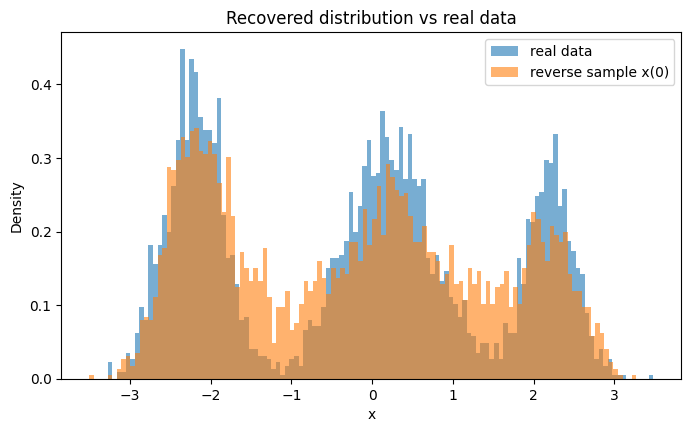

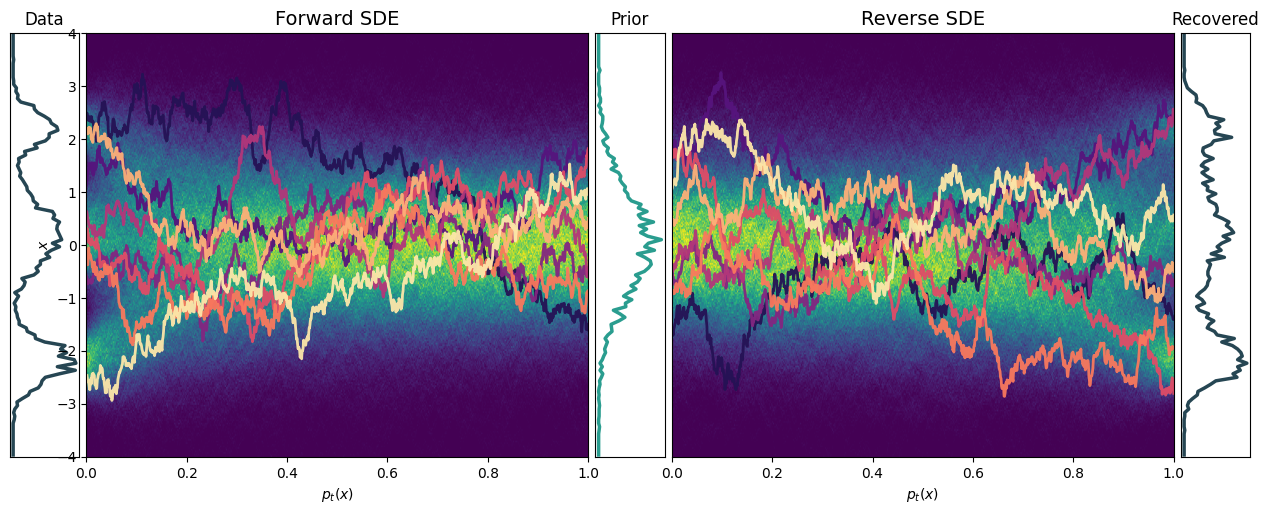

In [ ]:
# score_mlp_reverse_demo.py
# Minimal 1D diffusion demo: learn score from YOUR real samples, then run reverse SDE.
# Requirements: numpy, matplotlib, torch

import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# -----------------------------
# Load real 1D samples from file
# Supported: .npy, .npz, .csv, .txt
# -----------------------------
def load_real_samples(data_path, npz_key=None):
    path = Path(data_path)
    if not path.exists():
        raise FileNotFoundError(f"Data file not found: {path}")

    suffix = path.suffix.lower()
    if suffix == ".npy":
        arr = np.load(path)
    elif suffix == ".npz":
        data = np.load(path)
        if npz_key is None:
            if len(data.files) != 1:
                raise ValueError(
                    f"NPZ has multiple arrays {data.files}. Please set npz_key to one of them."
                )
            arr = data[data.files[0]]
        else:
            arr = data[npz_key]
    elif suffix == ".csv":
        arr = np.genfromtxt(path, delimiter=",", dtype=np.float64)
    elif suffix == ".txt":
        arr = np.loadtxt(path, dtype=np.float64)
    else:
        raise ValueError(f"Unsupported file type: {suffix}")

    arr = np.asarray(arr, dtype=np.float64).reshape(-1)
    arr = arr[np.isfinite(arr)]
    if arr.size < 100:
        raise ValueError("Need at least 100 finite samples to train a stable score model.")
    return arr


def make_empirical_sampler(x_real):
    x_real = np.asarray(x_real, dtype=np.float64).reshape(-1)

    def sample_x0(n, rng):
        idx = rng.integers(0, x_real.shape[0], size=n)
        return x_real[idx]

    return sample_x0


# -----------------------------
# Forward SDE (OU/VP constant beta):
#   dx = -0.5 * beta * x dt + sqrt(beta) dW
# Closed-form perturbation:
#   x_t = a(t) * x0 + s(t) * eps
# -----------------------------
def alpha_sigma_torch(t, beta):
    a = torch.exp(-0.5 * beta * t)
    s2 = 1.0 - torch.exp(-beta * t)
    s2 = torch.clamp(s2, min=1e-12)
    s = torch.sqrt(s2)
    return a, s, s2


# -----------------------------
# Tiny MLP score model s_theta(x,t)
# -----------------------------
class ScoreMLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)


# -----------------------------
# Train with denoising score matching (DSM) on real-data sampler
# -----------------------------
def train_score_net(data_sampler, rng_np, beta=6.0, T=1.0, steps=2000, batch_size=2048, lr=2e-3, device="cpu"):
    net = ScoreMLP(hidden=128).to(device)
    opt = optim.Adam(net.parameters(), lr=lr)

    for it in range(steps):
        x0_np = data_sampler(batch_size, rng_np).astype(np.float32)
        x0 = torch.from_numpy(x0_np).to(device).view(-1, 1)

        t = torch.rand(batch_size, 1, device=device) * T
        eps = torch.randn(batch_size, 1, device=device)

        a, s, s2 = alpha_sigma_torch(t, beta)
        x_t = a * x0 + s * eps
        target = -(x_t - a * x0) / s2

        pred = net(x_t, t)
        loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if (it + 1) % 500 == 0:
            print("iter", it + 1, "loss", float(loss.item()))

    return net


# -----------------------------
# Reverse SDE sampling using learned score
# -----------------------------
@torch.no_grad()
def reverse_sample_sde(net, n_paths=8000, beta=6.0, T=1.0, dt=1e-3, device="cpu", xT_start=None):
    n_steps = int(round(T / dt))
    if xT_start is None:
        x = torch.randn(n_paths, 1, device=device)
    else:
        x_init = np.asarray(xT_start, dtype=np.float32).reshape(-1)
        x = torch.from_numpy(x_init).to(device).view(-1, 1)
        n_paths = x.shape[0]

    X = torch.empty(n_paths, n_steps + 1, device=device)
    X[:, -1] = x.squeeze(1)

    noise_scale = math.sqrt(beta * dt)

    for k in range(n_steps, 0, -1):
        t_k = torch.full((n_paths, 1), k * dt, device=device)
        s = net(x, t_k)
        drift = 0.5 * beta * x + beta * s
        noise = torch.randn_like(x) * noise_scale
        x = x + drift * dt + noise
        X[:, k - 1] = x.squeeze(1)

    t_grid = torch.linspace(0.0, T, n_steps + 1, device=device)
    return t_grid.cpu().numpy(), X.cpu().numpy()


def simulate_forward_sde_paths(x0_np, beta=6.0, T=1.0, dt=1e-3, rng_np=None):
    if rng_np is None:
        rng_np = np.random.default_rng()

    n_paths = x0_np.shape[0]
    n_steps = int(round(T / dt))
    t = np.linspace(0.0, T, n_steps + 1)

    X = np.zeros((n_paths, n_steps + 1), dtype=np.float64)
    X[:, 0] = x0_np

    drift_c = -0.5 * beta
    noise_c = math.sqrt(beta * dt)

    for k in range(n_steps):
        z = rng_np.standard_normal(n_paths)
        X[:, k + 1] = X[:, k] + drift_c * X[:, k] * dt + noise_c * z

    return t, X


def estimate_density_grid_from_paths(X, x_grid):
    n_paths, n_t = X.shape
    n_x = len(x_grid)

    edges = np.zeros(n_x + 1)
    edges[1:-1] = 0.5 * (x_grid[:-1] + x_grid[1:])
    edges[0] = x_grid[0] - (edges[1] - x_grid[0])
    edges[-1] = x_grid[-1] + (x_grid[-1] - edges[-2])

    P = np.zeros((n_x, n_t), dtype=np.float64)
    for j in range(n_t):
        hist, _ = np.histogram(X[:, j], bins=edges, density=True)
        P[:, j] = hist
    return P


def vertical_density(ax, samples, x_grid, color="black", lw=2.0, title=None):
    hist, edges = np.histogram(samples, bins=120, range=(x_grid[0], x_grid[-1]), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.plot(hist, centers, color=color, lw=lw)
    ax.set_ylim(x_grid[0], x_grid[-1])
    ax.set_xticks([])
    ax.set_yticks([])
    if title is not None:
        ax.set_title(title, fontsize=12)


def plot_forward_reverse_sde_style(
    X_fwd,
    X_rev,
    T=1.0,
    xlim=(-4.0, 4.0),
    n_paths_line=8,
    cmap="viridis",
    density_clip_q=0.995,
    ):
    n_steps = X_fwd.shape[1] - 1
    t = np.linspace(0.0, T, n_steps + 1)

    X_rev_tau = X_rev[:, ::-1]
    tau = np.linspace(0.0, T, n_steps + 1)

    x_grid = np.linspace(xlim[0], xlim[1], 260)
    P_fwd = estimate_density_grid_from_paths(X_fwd, x_grid)
    P_rev = estimate_density_grid_from_paths(X_rev_tau, x_grid)
    P_fwd_vis = np.clip(P_fwd, 0, np.quantile(P_fwd, density_clip_q))
    P_rev_vis = np.clip(P_rev, 0, np.quantile(P_rev, density_clip_q))

    fig = plt.figure(figsize=(16, 5.5))
    gs = fig.add_gridspec(1, 5, width_ratios=[1.1, 8.0, 1.1, 8.0, 1.1], wspace=0.03)

    ax_l = fig.add_subplot(gs[0, 0])
    ax_f = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[0, 2])
    ax_r = fig.add_subplot(gs[0, 3])
    ax_rr = fig.add_subplot(gs[0, 4])

    vertical_density(ax_l, X_fwd[:, 0], x_grid, color="#264653", lw=2.5, title="Data")
    vertical_density(ax_c, X_fwd[:, -1], x_grid, color="#2a9d8f", lw=2.5, title="Prior")
    vertical_density(ax_rr, X_rev_tau[:, -1], x_grid, color="#264653", lw=2.5, title="Recovered")

    extent_f = [0.0, T, x_grid[0], x_grid[-1]]
    ax_f.imshow(P_fwd_vis, aspect="auto", origin="lower", extent=extent_f, cmap=cmap)
    ax_f.set_title("Forward SDE", fontsize=14)
    ax_f.set_xlabel(r"$p_t(x)$")
    ax_f.set_ylabel(r"$x$")
    ax_f.set_xlim(0.0, T)
    ax_f.set_ylim(xlim[0], xlim[1])

    idx_paths = np.random.choice(X_fwd.shape[0], size=min(n_paths_line, X_fwd.shape[0]), replace=False)
    line_colors = plt.cm.magma(np.linspace(0.15, 0.95, len(idx_paths)))
    for col, path_idx in zip(line_colors, idx_paths):
        ax_f.plot(t, X_fwd[path_idx], color=col, lw=2.0, alpha=0.95)

    extent_r = [0.0, T, x_grid[0], x_grid[-1]]
    ax_r.imshow(P_rev_vis, aspect="auto", origin="lower", extent=extent_r, cmap=cmap)
    ax_r.set_title("Reverse SDE", fontsize=14)
    ax_r.set_xlabel(r"$p_t(x)$")
    ax_r.set_ylabel("")
    ax_r.set_xlim(0.0, T)
    ax_r.set_ylim(xlim[0], xlim[1])
    ax_r.set_yticks([])

    for col, path_idx in zip(line_colors, idx_paths):
        ax_r.plot(tau, X_rev_tau[path_idx], color=col, lw=2.0, alpha=0.95)
    plt.show()


def main():
    rng = np.random.default_rng(0)
    device = "cpu"

    # ---- optional real data file ----
    # Set to your file path ('.npy' / '.npz' / '.csv' / '.txt').
    # If None or file not found, the demo falls back to a synthetic mixture sampler.
    data_path = None
    npz_key = None  # if using .npz with multiple arrays, set key name here

    def sample_x0_synthetic(n, rng):
        w = np.array([0.35, 0.45, 0.20])
        comp = rng.choice(len(w), size=n, p=w)
        means = np.array([-2.2, 0.2, 2.2])
        stds = np.array([0.35, 0.55, 0.30])
        return rng.normal(loc=means[comp], scale=stds[comp])

    if data_path is not None and Path(data_path).exists():
        x_real = load_real_samples(data_path, npz_key=npz_key)
        sample_x0 = make_empirical_sampler(x_real)
        print(f"Loaded real samples: n={x_real.size}, mean={x_real.mean():.4f}, std={x_real.std():.4f}")
    else:
        if data_path is None:
            print("No real data file provided. Using synthetic mixture sampler for demo.")
        else:
            print(f"Data file not found: {data_path}. Using synthetic mixture sampler for demo.")
        sample_x0 = sample_x0_synthetic

    beta = 6.0
    T = 1.0
    dt = 1e-3

    print("Training score network on your real samples...")
    net = train_score_net(
        data_sampler=sample_x0,
        rng_np=rng,
        beta=beta,
        T=T,
        steps=5000,
        batch_size=2048,
        lr=2e-3,
        device=device,
    )

    # One closed loop on the SAME batch: x0 -> forward to xT -> reverse back to x0_hat
    n_vis = 4000
    x0_vis = sample_x0(n_vis, rng)
    _, Xfwd_vis = simulate_forward_sde_paths(x0_vis, beta=beta, T=T, dt=dt, rng_np=rng)

    print("Reverse sampling from matched forward terminal states...")
    xT_vis = Xfwd_vis[:, -1]
    _, Xrev_vis = reverse_sample_sde(net, beta=beta, T=T, dt=dt, device=device, xT_start=xT_vis)

    x_true = Xfwd_vis[:, 0]
    x_rec = Xrev_vis[:, 0]

    plt.figure(figsize=(8, 4.5))
    plt.hist(x_true, bins=120, density=True, alpha=0.6, label="real data")
    plt.hist(x_rec, bins=120, density=True, alpha=0.6, label="reverse sample x(0)")
    plt.legend()
    plt.title("Recovered distribution vs real data")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.show()

    plot_forward_reverse_sde_style(
        X_fwd=Xfwd_vis,
        X_rev=Xrev_vis,
        T=T,
        xlim=(-4, 4),
        n_paths_line=8,
        cmap="viridis",
    )


AUTO_RUN_DEMO = False
if AUTO_RUN_DEMO:
    main()

In [ ]:
# Static renders for PDF export (interactive widgets do not reliably render in PDF)

plot_path_by_dt(delta_t=0.25)

plot_mixture2d_score_simple(w=0.50, m1x=-2.0, m2x=2.0, sigma=1.0)

plot_pdf_and_score(

    w=0.3,

    mu1=-2.5,

    sigma1=1.2,

    mu2=3.0,

    sigma2=1.0,

    x_min=-10.0,

    x_max=10.0,

)

## References


1. Stochastic Processes and SDEs: https://rbcborealis.com/research-blogs/stochastic-processes-and-sdes/


2. Score-Based Generative Modeling (Yang Song): https://yang-song.net/blog/2021/score/?utm_source=chatgpt.com